# 딥러닝 기초 IV — tips 회귀 + scikit-learn 전처리

이전 노트북(`tips_PyTorch_회귀_실습.ipynb`)은 **sklearn 없이** dict / `one_hot`으로 전처리했습니다.  
이번 노트북은 같은 문제를 **`scikit-learn` 문법**으로 전처리한 뒤, PyTorch로 회귀합니다.

**학습 목표**
- `train_test_split` → `fit` / `transform` 순서로 누수 방지
- `StandardScaler`, `OneHotEncoder`, `ColumnTransformer` 사용
- 전처리된 배열을 PyTorch 텐서로 바꿔 `nn.Sequential` 학습

**제약 (교육용)**
- 사용자 정의 `def` / `class` 금지
- 모델은 `nn.Sequential` (출력 1, 활성화 없음)
- 스케일러·인코더는 **Train에만 `fit`**, Val에는 `transform`만


## 0. Data Leakage 방지 + sklearn 역할

### 올바른 순서
```
1) train_test_split으로 분리
2) ColumnTransformer.fit(X_train)   ← Train만!
3) X_train_p = transform(X_train)
   X_val_p   = transform(X_val)
4) PyTorch 텐서로 변환 후 학습
```

### 이번 실습에서 쓰는 sklearn API
| 도구 | 역할 |
|------|------|
| `train_test_split` | Train / Val 분리 |
| `StandardScaler` | 수치형 표준화 |
| `OneHotEncoder` | 범주형 원-핫 |
| `ColumnTransformer` | 수치·범주 전처리를 한 번에 |


## 1. 환경 설정


In [ ]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from torch.utils.data import TensorDataset, DataLoader

if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('device:', device)


Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

## 2. 데이터 로드와 Train / Validation 분리

### tips
- target: `tip`
- 수치형: `total_bill`, `size`
- 범주형: `sex`, `smoker`, `day`, `time`

### `train_test_split`
전처리 **전에** 분리합니다.


In [ ]:
df = sns.load_dataset('tips').copy()
print(df.head())
print('shape:', df.shape)

y = df['tip'].to_numpy(dtype=np.float32)
X = df.drop(columns=['tip'])

num_cols = ['total_bill', 'size']
cat_cols = ['sex', 'smoker', 'day', 'time']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
)

print('train:', X_train.shape, 'val:', X_val.shape)
print(X_train.head(3))


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
shape: (244, 7)
train: (195, 6) val: (49, 6)
     total_bill   sex smoker  day    time  size
228       13.28  Male     No  Sat  Dinner     2
208       24.27  Male    Yes  Sat  Dinner     2
96        27.28  Male    Yes  Fri  Dinner     2


## 3. scikit-learn 전처리 (`ColumnTransformer`)

### 구성
- 수치형 → `StandardScaler`
- 범주형 → `OneHotEncoder(handle_unknown='ignore')`
  - Val에 Train에 없던 카테고리가 나와도 안전하게 무시

### 핵심
`fit`은 **X_train만**, Val은 `transform`만.


In [ ]:
# 코드

X_train_p: (195, 12)
X_val_p  : (49, 12)
feature names (일부): ['num__total_bill', 'num__size', 'cat__sex_Female', 'cat__sex_Male', 'cat__smoker_No', 'cat__smoker_Yes', 'cat__day_Fri', 'cat__day_Sat'] ...


### (참고) fit 결과 확인
Train에서 학습된 스케일러 평균·원-핫 카테고리를 살펴봅니다.


In [ ]:
# 코드

StandardScaler mean_: [20.21769231  2.57435897]
StandardScaler scale_: [8.74798722 0.93827937]
OneHot categories_:
  sex: ['Female', 'Male']
  smoker: ['No', 'Yes']
  day: ['Fri', 'Sat', 'Sun', 'Thur']
  time: ['Dinner', 'Lunch']


## 4. PyTorch 텐서 / DataLoader


In [ ]:
# 코드

input_dim = 12


## 5. 회귀 모델 (`nn.Sequential`)

이전(순수 PyTorch 전처리) 노트북과 **동일한 아키텍처**입니다.


In [ ]:
# 코드

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


## 6. 모델 학습


In [ ]:
# 코드

Epoch 001/80 | train_mse=9.7056 | val_mse=6.1442
Epoch 010/80 | train_mse=1.4102 | val_mse=1.2439
Epoch 020/80 | train_mse=1.1445 | val_mse=0.8487
Epoch 030/80 | train_mse=1.0816 | val_mse=0.7667
Epoch 040/80 | train_mse=1.0410 | val_mse=0.7400
Epoch 050/80 | train_mse=0.9723 | val_mse=0.9200
Epoch 060/80 | train_mse=0.9422 | val_mse=0.8662
Epoch 070/80 | train_mse=0.8885 | val_mse=1.0624
Epoch 080/80 | train_mse=0.8487 | val_mse=0.9644


## 7. 학습 곡선 시각화

### Direct Labeling (1행 2열)
`ax.legend()` 없이 곡선 끝 우측에 이름 표시, `xlim` 여백 확보


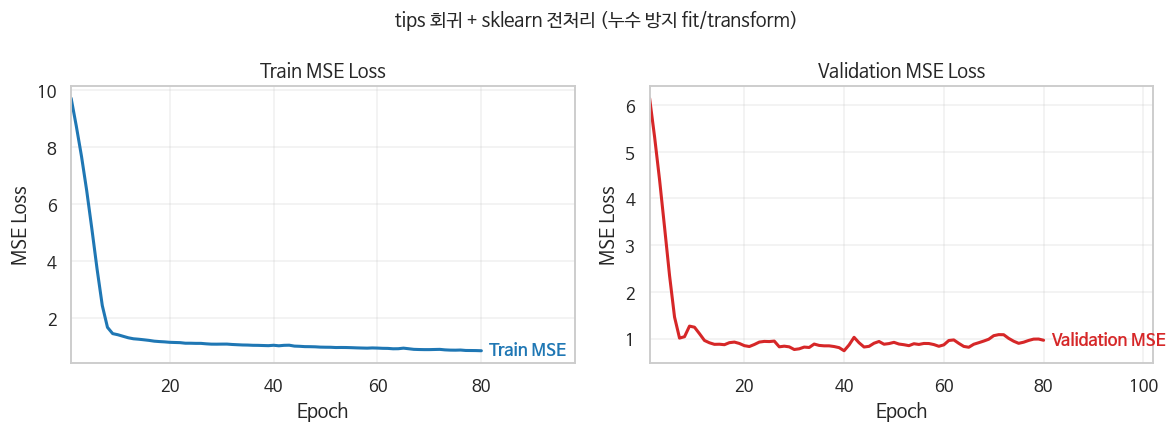

In [ ]:
epochs_x = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_x, train_losses, color='#1f77b4', linewidth=2)
axes[0].text(
    epochs_x[-1] + 1.5, train_losses[-1], 'Train MSE',
    color='#1f77b4', va='center', fontsize=11, fontweight='bold',
)
axes[0].set_xlim(1, EPOCHS + 18)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Train MSE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, val_losses, color='#d62728', linewidth=2)
axes[1].text(
    epochs_x[-1] + 1.5, val_losses[-1], 'Validation MSE',
    color='#d62728', va='center', fontsize=11, fontweight='bold',
)
axes[1].set_xlim(1, EPOCHS + 22)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Validation MSE Loss')
axes[1].grid(alpha=0.3)

fig.suptitle('tips 회귀 + sklearn 전처리 (누수 방지 fit/transform)', fontsize=12)
fig.tight_layout()
plt.show()


## 8. 평가와 예측 시각화


Validation MAE  = 0.7794
Validation RMSE = 0.9821


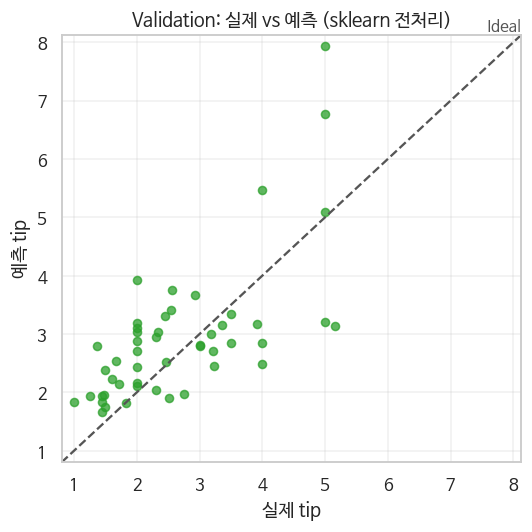

In [ ]:
# 코드

## 9. 순수 PyTorch 전처리 vs sklearn 전처리 비교

| 항목 | 순수 PyTorch 노트북 | 이번 (sklearn) 노트북 |
|------|---------------------|------------------------|
| 분리 | 인덱스 `permutation` | `train_test_split` |
| 수치형 | 수동 mean/std | `StandardScaler` |
| 범주형 | `dict` + `F.one_hot` | `OneHotEncoder` |
| 묶음 | `torch.cat` | `ColumnTransformer` |
| 누수 방지 | Train 통계만 사용 | `fit(X_train)`만 |
| 모델 | 동일 `nn.Sequential` | 동일 |

실무에서는 `ColumnTransformer`가 짧고 실수가 적습니다.  
원리를 이해하려면 순수 PyTorch 전처리 노트북을 함께 보세요.
